In [1]:
from typing_extensions import Literal
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from langgraph.graph import MessagesState, StateGraph,START,END
from langgraph.types import Command
from dotenv import load_dotenv
from IPython.display import Image, display
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage, HumanMessage
from typing import Annotated
# from langchain_experimental.utilities import PythonREPL

C:\Users\ssaty\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:

load_dotenv()
groq_model=ChatGroq(model="openai/gpt-oss-120b")

In [36]:

def add_numbers(state):
    result=state["num1"]+state["num2"]
    print(f"additional result: {result}")
    return Command(goto="multiply",update={"sum":result})

In [37]:

state={"num1":1, "num2":2}



In [38]:

add_numbers(state)

additional result: 3


Command(update={'sum': 3}, goto='multiply')

In [39]:
@tool
def transfer_to_multiplication_expert(reason: str) -> str:
    """Ask multiplication agent for help"""
    return 

In [40]:
@tool
def transfer_to_addition_expert(reason: str) -> str:
    """Ask addition agent for help"""
    return

In [41]:
model_with_tool=groq_model.bind_tools([transfer_to_multiplication_expert])


In [42]:

ai_message=model_with_tool.invoke("hi how are you?")


In [44]:

ai_message.tool_calls

[]

In [45]:
ai_message=model_with_tool.invoke("what's (3 + 5) * 12. Provide me the output")


In [ ]:

ai_message.tool_calls

[{'name': 'transfer_to_multiplication_expert',
  'args': {},
  'id': 'hz7jngew3',
  'type': 'tool_call'}]

In [46]:
def additional_expert(state:MessagesState)-> Command[Literal["multiplication_expert", "__end__"]]:
    
    system_prompt = (
        "You are an addition expert. You excel at solving addition problems. "
        "When you need help with multiplication, use the transfer_to_multiplication_expert tool with a reason for the handoff. "
        "Always do your portion of calculation before requesting a handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    
    ai_msg = groq_model.bind_tools([transfer_to_multiplication_expert]).invoke(messages)
    
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred to multiplication expert",
            "tool_call_id": tool_call_id,
        }
        
        return Command(
            goto="multiplication_expert", update={"messages": [ai_msg, tool_msg]}
        )
    return {"messages": [ai_msg]}

In [13]:
def multiplication_expert(state:MessagesState)-> Command[Literal["additional_expert", "__end__"]]:
    
    system_prompt = (
        "You are a multiplication expert. You excel at solving multiplication problems. "
        "When you need help with addition, use the transfer_to_addition_expert tool with a reason for the handoff. "
        "Always do your portion of calculation before requesting a handoff."
    )
    
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    
    ai_msg = groq_model.bind_tools([transfer_to_addition_expert]).invoke(messages)
    
    if len(ai_msg.tool_calls) > 0:
        tool_call_id = ai_msg.tool_calls[-1]["id"]
        tool_msg = {
            "role": "tool",
            "content": "Successfully transferred to addition expert",
            "tool_call_id": tool_call_id,
        }
        return Command(goto="additional_expert", update={"messages": [ai_msg, tool_msg]})
    return {"messages": [ai_msg]}

In [47]:

graph=StateGraph(MessagesState)

In [48]:

graph.add_node("additional_expert",additional_expert)
graph.add_node("multiplication_expert",multiplication_expert)

In [49]:

graph.add_edge(START, "additional_expert")

In [50]:

app=graph.compile()

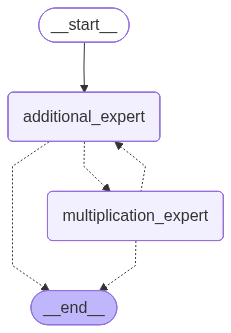

In [51]:

display(Image(app.get_graph().draw_mermaid_png()))


In [52]:
app.invoke({"messages":[("user","what's (3 + 5) * 12. Provide me the output")]})

{'messages': [HumanMessage(content="what's (3 + 5) * 12. Provide me the output", additional_kwargs={}, response_metadata={}, id='0ded40dc-f9e4-491a-9348-56c2b88d5d0f'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "what\'s (3 + 5) * 12. Provide me the output". This is a multiplication problem: (3+5)=8, then 8*12 = 96. The user wants the output. According to instructions, we are addition expert, but need multiplication. We can do addition first: 3+5 = 8. Then multiplication: 8*12 = 96. According to policy, we should do our portion (addition) before requesting handoff. So we compute sum = 8. Then we need to multiply 8 by 12. Must hand off to multiplication expert. Provide reason: need multiplication. So call transfer_to_multiplication_expert with reason.', 'tool_calls': [{'id': 'fc_a9308236-16d4-4fb2-a171-b8b4a8bfa7c2', 'function': {'arguments': '{"reason":"Need to multiply 8 by 12 after performing addition."}', 'name': 'transfer_to_multiplication_expert'},

In [53]:
from langchain_core.messages import convert_to_messages
def pretty_print_messages(update):
    if isinstance(update, tuple):
        ns, update = update
        # skip parent graph updates in the printouts
        if len(ns) == 0:
            return

        graph_id = ns[-1].split(":")[0]
        print(f"Update from subgraph {graph_id}:")
        print("\n")

    for node_name, node_update in update.items():
        print(f"Update from node {node_name}:")
        print("\n")

        for m in convert_to_messages(node_update["messages"]):
            m.pretty_print()
        print("\n")

In [54]:

# Let's run the graph with an expression that requires both addition and multiplication:
for chunk in app.stream(
    {"messages": [("user", "what's (3 + 5) * 12. Provide me the output")]},
):
    print("****chunk...****")
    
    pretty_print_messages(chunk)

****chunk...****
Update from node additional_expert:


================================== Ai Message ==================================
Tool Calls:
  transfer_to_multiplication_expert (fc_6bd4172f-9d1b-4a82-98b3-4edb948a8390)
 Call ID: fc_6bd4172f-9d1b-4a82-98b3-4edb948a8390
  Args:
    reason: Need to compute 8 * 12 after performing addition
================================= Tool Message =================================

Successfully transferred to multiplication expert


****chunk...****
Update from node multiplication_expert:


================================== Ai Message ==================================

The expression evaluates to \( (3 + 5) \times 12 = 8 \times 12 = 96 \).


